# Finding an attacking left-back in the Indian Super League (2021/22)

A data-driven scouting exercise using StatsBomb open data.

**Question.** A modest club can't buy the €40M full-back. It goes to undervalued
markets to find 80% of the output for 10% of the fee. Within one fully-covered
league, who is the most productive *attacking* left-back?

**Why this league.** Coverage due-diligence (`scripts/coverage_check.py`) ruled
out the alternatives: MLS 2023 open data is only 6 matches, and La Liga open
data is Barcelona's matches only. The Indian Super League 2021/22 is the one
option with a full season (115 matches, 11 teams) — a rankable pool.

**Method.**
1. Load and cache the season's events.
2. Build a clean pool of *genuine* left-backs (modal position = LB/LWB, ≥ 900').
3. Compute attacking metrics per 90 minutes.
4. Rank within the league as percentiles.

**Caveats stated up front.** The pool is small (N ≈ 13), so percentiles are
coarse — read them as "2nd of 13", not "top 5%". Metrics are per-90 within one
league; cross-league comparison would need a league-strength adjustment that
open data doesn't provide. Two players are positional hybrids (low `share_LB`)
and are flagged, not hidden.

## 1. Setup and load

In [2]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# resolve repo root wherever the notebook runs from (it lives in notebooks/)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.append(str(ROOT))          # so we can import the src/ package

from src.isl import load_isl_events, build_left_back_pool

ev = load_isl_events(ROOT / "data/raw/isl_2122_events.pkl")
print("Events:", ev.shape)

Events: (344667, 116)


## 2. Clean pool of left-backs

`build_left_back_pool` keeps only players whose *modal* position is LB/LWB and
who cleared 900 minutes. `share_LB` shows how much of each player's time was
actually spent at left-back — the two low values are hybrids to flag later.

In [3]:
pool = build_left_back_pool(ev, min_minutes=900)
print(f"Pool: {len(pool)} left-backs with >=900 min")
pool

Pool: 13 left-backs with >=900 min


,minutes,modal_pos,share_LB,team
player,,,,
Akash Mishra,2140,Left Back,99.0,Hyderabad
Ricky Lallawmawma,2092,Left Back,100.0,Jamshedpur
Subhasish Bose,1929,Left Back,89.0,ATK Mohun Bagan
Jerry Lalrinzuala,1639,Left Wing Back,98.0,Chennaiyin
Naorem Roshan Singh,1552,Left Back,49.0,Bengaluru
Hira Mondal,1461,Left Back,78.0,East Bengal
Gurjinder Kumar,1380,Left Back,100.0,NorthEast United
Sahil Panwar,1176,Left Back,94.0,Odisha
Muhammad Ashique Kuruniyan,1073,Left Back,94.0,Bengaluru


## 3. Unpack location lists into flat columns

StatsBomb stores position as a `[x, y]` list inside a single cell, and many
events have no location (`NaN`). `coord` returns the i-th element for lists and
`NaN` otherwise, so we get clean numeric `x`, `y`, `end_x`... columns to filter
on. The pitch is **120 x 80**.

In [5]:
def coord(v, i):
    return v[i] if isinstance(v, (list, tuple)) else np.nan

ev["x"]           = ev["location"].apply(lambda v: coord(v, 0))
ev["y"]           = ev["location"].apply(lambda v: coord(v, 1))
ev["end_x"]       = ev["pass_end_location"].apply(lambda v: coord(v, 0))
ev["end_y"]       = ev["pass_end_location"].apply(lambda v: coord(v, 1))
ev["carry_end_x"] = ev["carry_end_location"].apply(lambda v: coord(v, 0))

## 4. Attacking metrics, normalised per 90

Metrics chosen because event data captures them with little ambiguity for a
full-back: crosses (and completion %), open-play passes into the box,
shot assists (a pass leading to a shot — our free proxy for xA), progressive
carries, and final-third touches.

Two StatsBomb conventions to remember: a **completed** pass has an *empty*
`pass_outcome` (so `.isna()` means completed), and an **open-play** pass has an
empty `pass_type`. The box is `x >= 102`, `y` in 18–62; the final third is
`x >= 80`.

In [6]:
evp = ev[ev["player"].isin(pool.index)].copy()

open_play = evp["pass_type"].isna()      # not corner / free-kick / throw-in
completed = evp["pass_outcome"].isna()   # empty outcome = completed pass

evp["cross"]       = (evp["pass_cross"] == True) & open_play
evp["cross_cmp"]   = evp["cross"] & completed
evp["box_pass"]    = ((evp["type"] == "Pass") & open_play & completed
                      & (evp["end_x"] >= 102) & evp["end_y"].between(18, 62)
                      & (evp["x"] < 102))
evp["shot_assist"] = (evp["pass_shot_assist"] == True)
evp["prog_carry"]  = (evp["type"] == "Carry") & ((evp["carry_end_x"] - evp["x"]) >= 5)
evp["f3_touch"]    = (evp["x"] >= 80)

flags = ["cross", "cross_cmp", "box_pass", "shot_assist", "prog_carry", "f3_touch"]
totals = evp.groupby("player")[flags].sum()

df = pool.join(totals)
per90 = df[flags].div(df["minutes"], axis=0).mul(90).round(2)
per90.columns = ["crosses", "crosses_cmp", "box_passes", "shot_assists",
                 "prog_carries", "f3_touches"]
per90["cross_pct"] = (df["cross_cmp"] / df["cross"] * 100).round(0)

profile = pool[["team", "minutes", "share_LB"]].join(per90)
profile.sort_values("box_passes", ascending=False)

,team,minutes,share_LB,crosses,crosses_cmp,box_passes,shot_assists,prog_carries,f3_touches,cross_pct
player,,,,,,,,,,
Saviour Gama,Goa,946,93.0,1.52,0.57,0.67,0.57,5.42,47.76,38.0
Jessel Carneiro,Kerala Blasters,950,100.0,1.23,0.38,0.66,0.38,3.32,18.76,31.0
Naorem Roshan Singh,Bengaluru,1552,49.0,1.57,0.70,0.64,1.62,8.99,34.39,44.0
Muhammad Ashique Kuruniyan,Bengaluru,1073,94.0,2.35,0.50,0.59,0.50,8.72,38.33,21.0
Ricky Lallawmawma,Jamshedpur,2092,100.0,1.68,0.34,0.47,0.52,4.60,32.70,21.0
Mandar Rao Desai,Mumbai City,985,100.0,1.92,0.18,0.46,0.55,5.30,34.26,10.0
Gurjinder Kumar,NorthEast United,1380,100.0,1.37,0.26,0.39,0.52,6.26,28.30,19.0
Lalruatthara Lalruatthara,Odisha,922,67.0,0.78,0.10,0.39,0.10,5.17,18.55,12.0
Akash Mishra,Hyderabad,2140,99.0,1.39,0.50,0.34,0.71,10.26,27.93,36.0


## 5. Percentiles within the league

`rank(pct=True)` turns each metric into its percentile among the 13. With this
sample size, phrase findings as ranks ("2nd of 13"), and asterisk the hybrids
(low `share_LB`) whose per-90 blends minutes from another position.

In [7]:
metrics = ["crosses", "box_passes", "shot_assists", "prog_carries", "f3_touches"]
pct = profile[metrics].rank(pct=True).mul(100).round(0)
pct.columns = [c + "_pctl" for c in metrics]
pct.join(profile[["team", "minutes", "share_LB"]]).sort_values("box_passes_pctl", ascending=False)

,crosses_pctl,box_passes_pctl,shot_assists_pctl,prog_carries_pctl,f3_touches_pctl,team,minutes,share_LB
player,,,,,,,,
Saviour Gama,69.0,100.0,77.0,54.0,100.0,Goa,946,93.0
Jessel Carneiro,31.0,92.0,23.0,15.0,31.0,Kerala Blasters,950,100.0
Naorem Roshan Singh,77.0,85.0,100.0,92.0,77.0,Bengaluru,1552,49.0
Muhammad Ashique Kuruniyan,100.0,77.0,46.0,85.0,92.0,Bengaluru,1073,94.0
Ricky Lallawmawma,85.0,69.0,58.0,23.0,62.0,Jamshedpur,2092,100.0
Mandar Rao Desai,92.0,62.0,69.0,46.0,69.0,Mumbai City,985,100.0
Gurjinder Kumar,50.0,50.0,58.0,69.0,54.0,NorthEast United,1380,100.0
Lalruatthara Lalruatthara,15.0,50.0,15.0,38.0,23.0,Odisha,922,67.0
Akash Mishra,62.0,38.0,92.0,100.0,46.0,Hyderabad,2140,99.0


## 6. Next — visualise the standout

Once the target is chosen, build a radar / pizza chart with `mplsoccer` and a
written positional evaluation. That figure and write-up become the featured
piece linked from the README.

saved: C:\Users\migue\Desktop\futbol-analytics\reports\figures\pizza_muhammad_ashique_kuruniyan.png


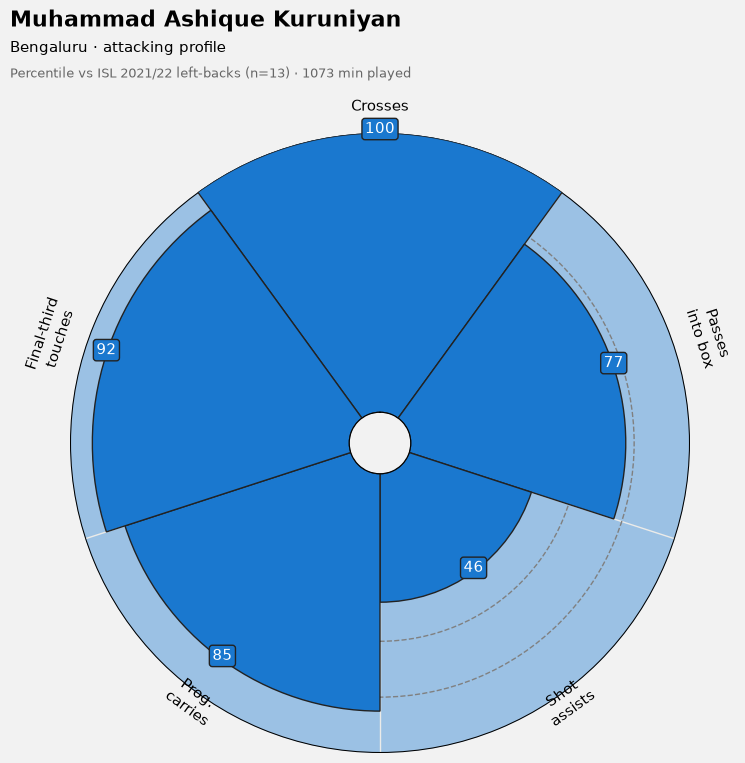

In [10]:
from mplsoccer import PyPizza

PLAYER = "Muhammad Ashique Kuruniyan"      

params = ["Crosses", "Passes\ninto box", "Shot\nassists", "Prog.\ncarries", "Final-third\ntouches"]
cols   = ["crosses_pctl", "box_passes_pctl", "shot_assists_pctl", "prog_carries_pctl", "f3_touches_pctl"]
values = pct.loc[PLAYER, cols].astype(int).tolist()

baker = PyPizza(
    params=params,
    straight_line_color="#EBEBE9",
    straight_line_lw=1,
    last_circle_lw=1.5,
    other_circle_lw=1,
    inner_circle_size=11,
)
fig, ax = baker.make_pizza(
    values,
    figsize=(8, 8.5),
    color_blank_space="same",
    slice_colors=["#1A78CF"] * 5,
    value_colors=["#FFFFFF"] * 5,
    value_bck_colors=["#1A78CF"] * 5,
    blank_alpha=0.4,
    kwargs_slices=dict(edgecolor="#222222", zorder=2, linewidth=1),
    kwargs_params=dict(color="#000000", fontsize=11),
    kwargs_values=dict(color="#FFFFFF", fontsize=11, zorder=3,
                       bbox=dict(edgecolor="#222222", facecolor="#1A78CF",
                                 boxstyle="round,pad=0.2", lw=1)),
)

team = profile.loc[PLAYER, "team"]
mins = int(profile.loc[PLAYER, "minutes"])
fig.text(0.05, 0.985, PLAYER, size=16, weight="bold", color="#000000")
fig.text(0.05, 0.955, f"{team} · attacking profile", size=11, color="#000000")
fig.text(0.05, 0.925,
         f"Percentile vs ISL 2021/22 left-backs (n=13) · {mins} min played",
         size=9, color="#666666")

out = ROOT / "reports/figures"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / f"pizza_{PLAYER.replace(' ', '_').lower()}.png", dpi=150, bbox_inches="tight")
print("saved:", out / f"pizza_{PLAYER.replace(' ', '_').lower()}.png")